# **Screen Time Analysis of Indian Children**

### About the Dataset

**Source:** Kaggle  
**Dataset:** [Indian Kids Screentime 2025](https://www.kaggle.com/datasets/ankushpanday2/indian-kids-screentime-2025/data)

### Objective

The goal of this analysis is to explore screen-time patterns among Indian children and answer a few key questions:

- Does screen time vary across age groups?
- Is screen time associated with health impacts?
- Do different devices show different usage patterns?
- Is there a difference between urban and rural users?

The analysis includes **data cleaning**, **exploratory data analysis (EDA)**, and **statistical testing** to identify meaningful patterns in the data.

### **Data loading and initial exploration**

In [ ]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

sns.set_theme(style='whitegrid', palette='deep')

In [ ]:
# Loading the dataset
df=pd.read_csv('/content/Indian_Kids_Screen_Time.csv')
df.head()

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban
3,15,Female,1.21,Laptop,False,0.39,NaN,Urban
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban


In [ ]:
# Renaming columns for easier coding and readability
df.rename(columns={
    'Age':'age',
    'Gender':'gender',
    'Avg_Daily_Screen_Time_hr':'avg_scr',
    'Primary_Device':'primary_device',
    'Exceeded_Recommended_Limit':'exceeding',
    'Educational_to_Recreational_Ratio':'ratio',
    'Health_Impacts':'health_impacts',
    'Urban_or_Rural':'urban_or_rural'
  },inplace=True)

In [ ]:
# Looking into the data types of columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9712 entries, 0 to 9711
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             9712 non-null   int64  
 1   gender          9712 non-null   object 
 2   avg_scr         9712 non-null   float64
 3   primary_device  9712 non-null   object 
 4   exceeding       9712 non-null   bool   
 5   ratio           9712 non-null   float64
 6   health_impacts  6494 non-null   object 
 7   urban_or_rural  9712 non-null   object 
dtypes: bool(1), float64(2), int64(1), object(4)
memory usage: 540.7+ KB


In [ ]:
# Checking and removing duplicates
print('dimension: ',df.shape)
print('\nnumber of duplicates:',df.duplicated().sum())
df.drop_duplicates(inplace=True)

dimension:  (9712, 8)

number of duplicates: 44


In [ ]:
# Understanding numerical columns
df.describe().round(2)

,age,avg_scr,ratio
count,9668.00,9668.00,9668.00
mean,12.99,4.37,0.43
std,3.16,1.70,0.07
min,8.00,0.00,0.30
25%,10.00,3.43,0.37
50%,13.00,4.44,0.43
75%,16.00,5.38,0.48
max,18.00,13.89,0.60


In [ ]:
# Checking for null values
df.isnull().sum()

,0
age,0
gender,0
avg_scr,0
primary_device,0
exceeding,0
ratio,0
health_impacts,3180
urban_or_rural,0


In [ ]:
# Investigating the huge number of missing values in health_impacts
df[df['health_impacts'].isnull()].sample(10)

,age,gender,avg_scr,primary_device,exceeding,ratio,health_impacts,urban_or_rural
1775,9,Male,1.56,Tablet,False,0.48,NaN,Urban
7626,10,Female,0.94,Smartphone,False,0.50,NaN,Urban
4321,10,Female,0.00,Smartphone,False,0.52,NaN,Rural
7507,8,Male,11.50,TV,True,0.58,NaN,Rural
9060,16,Male,2.82,Smartphone,False,0.50,NaN,Urban
6674,8,Male,0.00,TV,False,0.52,NaN,Rural
3520,14,Male,4.53,Smartphone,True,0.35,NaN,Urban
763,8,Female,6.02,TV,True,0.44,NaN,Urban
1840,15,Female,4.64,Smartphone,True,0.40,NaN,Rural
6491,14,Female,3.49,Laptop,True,0.45,NaN,Urban


In [ ]:
comparison=df.groupby(df['health_impacts'].isna())['avg_scr'].agg(['count', 'mean', 'median', 'std', 'min', 'max'])
comparison.index=['Reported impacts','Missing impacts']
comparison

,count,mean,median,std,min,max
Reported impacts,6488,4.917965,4.75,1.256611,3.01,13.89
Missing impacts,3180,3.245264,2.90,1.928420,0.00,12.40


***Insight***  

Users with reported health impacts have a higher count and average screen time. However missing values does not necessarily indicate the absence of health impacts\
This may indicate inconsistencies in recording or data collection.\
Since we do not know the cause of missing values, to avoid inaccuracies these values are retained and filled with 'Unknown'

In [ ]:
df['health_impacts']=df['health_impacts'].fillna('Unknown')

In [ ]:
df['health_impacts'].unique()

array(['Poor Sleep, Eye Strain', 'Poor Sleep', 'Unknown',
       'Poor Sleep, Anxiety', 'Poor Sleep, Obesity Risk', 'Eye Strain',
       'Obesity Risk', 'Anxiety', 'Poor Sleep, Anxiety, Obesity Risk',
       'Eye Strain, Obesity Risk', 'Eye Strain, Anxiety, Obesity Risk',
       'Anxiety, Obesity Risk', 'Poor Sleep, Eye Strain, Obesity Risk',
       'Poor Sleep, Eye Strain, Anxiety',
       'Poor Sleep, Eye Strain, Anxiety, Obesity Risk',
       'Eye Strain, Anxiety'], dtype=object)

### Creating a Health Impact List
Some records contain multiple health impacts in a single cell (e.g., "Poor Sleep, Eye Strain"). These values are split into a list format to simplify further analysis and allow individual health impacts to be examined separately.

In [ ]:
df['health_list'] = df['health_impacts'].str.split(',')

df['health_list'] = df['health_list'].apply(
    lambda x: [i.strip().title() for i in x] if isinstance(x, list) else ['Unknown']
)

In [ ]:
# Creating an exploded dataset
explode=df.explode('health_list')
explode['health_list'].value_counts()

,count
health_list,
Poor Sleep,4862
Unknown,3180
Eye Strain,2381
Anxiety,1604
Obesity Risk,1217


In [ ]:
# Creating binary columns for each health impact
df['poor_sleep']=df['health_impacts'].str.contains('Poor Sleep',na=False).astype(int)
df['eye_strain']=df['health_impacts'].str.contains('Eye Strain',na=False).astype(int)
df['anxiety']=df['health_impacts'].str.contains('Anxiety',na=False).astype(int)
df['obesity_risk']=df['health_impacts'].str.contains('Obesity Risk',na=False).astype(int)

Two datasets are created for different purposes:

- **df**: The main dataset used for overall analysis and statistical testing.
- **explode**: An exploded version of the dataset where each health impact is stored in a separate row.

In addition, binary indicator columns are created for each health impact to support correlation analysis, hypothesis testing, and comparisons of screen time across different health conditions.

In [ ]:
df.head()

,age,gender,avg_scr,primary_device,exceeding,ratio,health_impacts,urban_or_rural,health_list,poor_sleep,eye_strain,anxiety,obesity_risk
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban,"[Poor Sleep, Eye Strain]",1,1,0,0
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban,[Poor Sleep],1,0,0,0
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban,[Poor Sleep],1,0,0,0
3,15,Female,1.21,Laptop,False,0.39,Unknown,Urban,[Unknown],0,0,0,0
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban,"[Poor Sleep, Anxiety]",1,0,1,0


In [ ]:
explode.head()

,age,gender,avg_scr,primary_device,exceeding,ratio,health_impacts,urban_or_rural,health_list
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban,Poor Sleep
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban,Eye Strain
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban,Poor Sleep
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban,Poor Sleep
3,15,Female,1.21,Laptop,False,0.39,Unknown,Urban,Unknown


In [ ]:
df.describe()

,age,avg_scr,ratio,poor_sleep,eye_strain,anxiety,obesity_risk
count,9668.000000,9668.000000,9668.000000,9668.000000,9668.000000,9668.000000,9668.000000
mean,12.992760,4.367780,0.427028,0.502896,0.246276,0.165908,0.125879
std,3.158931,1.703002,0.073185,0.500017,0.430864,0.372017,0.331730
min,8.000000,0.000000,0.300000,0.000000,0.000000,0.000000,0.000000
25%,10.000000,3.427500,0.370000,0.000000,0.000000,0.000000,0.000000
50%,13.000000,4.440000,0.430000,1.000000,0.000000,0.000000,0.000000
75%,16.000000,5.380000,0.480000,1.000000,0.000000,0.000000,0.000000
max,18.000000,13.890000,0.600000,1.000000,1.000000,1.000000,1.000000


In [ ]:
explode.describe()

,age,avg_scr,ratio
count,13244.000000,13244.000000,13244.000000
mean,13.114165,4.512944,0.424578
std,3.121848,1.600516,0.072648
min,8.000000,0.000000,0.300000
25%,10.000000,3.630000,0.370000
50%,13.000000,4.550000,0.420000
75%,16.000000,5.450000,0.470000
max,18.000000,13.890000,0.600000


The exploded dataset preserved the original numerical distribution, indicating the transformation did not introduce major bias

# **Exploratory Data Analysis (EDA)**

## Univariate Analysis

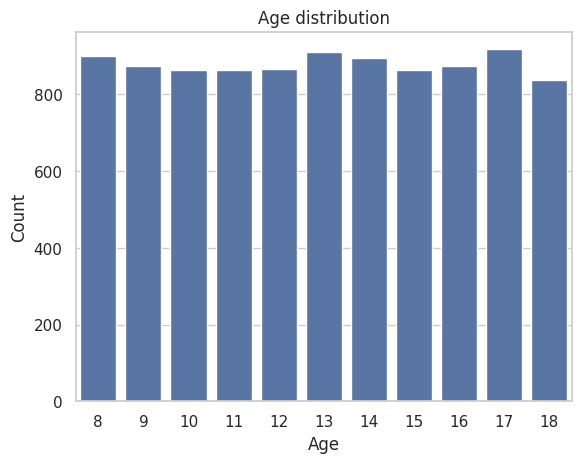

In [ ]:
plt.title('Age distribution')
plt.xlabel('Age')
plt.ylabel('Count')
sns.countplot(x='age', data=df)
plt.show()

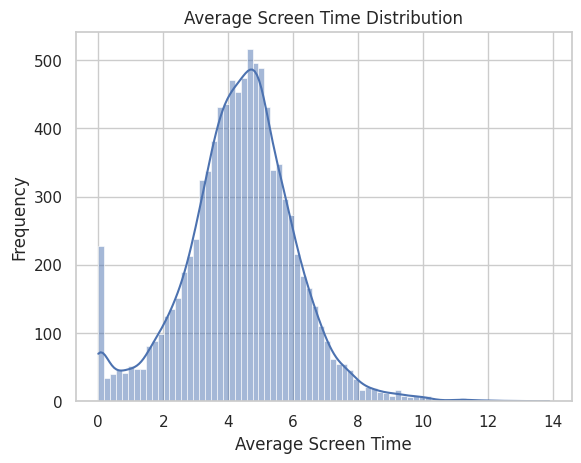

In [ ]:
sns.histplot(df['avg_scr'], kde=True)
plt.title('Average Screen Time Distribution')
plt.xlabel('Average Screen Time')
plt.ylabel('Frequency')
plt.show()

### ***Insight***
- Most children report around 4–5 hours of screen time per day.
- The distribution is positively skewed, with a small number of children reporting extremely high screen time values.
- A noticeable spike at 0 hours is questionable

In [ ]:
# Investigating the spike at 0 hours
print('Count of values at 0 hours:',(df['avg_scr']==0).sum())
print('\nchecking the table\n',df[df['avg_scr'] == 0][['age','primary_device','ratio','health_impacts']].sample(5))
print('\nchecking numerical values\n',df[df['avg_scr']==0].describe())

Count of values at 0 hours: 194

checking the table
       age primary_device  ratio health_impacts
5327   10             TV   0.59        Unknown
3467   10     Smartphone   0.44        Unknown
7898   10             TV   0.51        Unknown
7716   10     Smartphone   0.56        Unknown
738     8     Smartphone   0.54        Unknown

checking numerical values
               age  avg_scr       ratio  poor_sleep  eye_strain  anxiety  \
count  194.000000    194.0  194.000000       194.0       194.0    194.0   
mean     9.149485      0.0    0.502835         0.0         0.0      0.0   
std      0.993932      0.0    0.060041         0.0         0.0      0.0   
min      8.000000      0.0    0.400000         0.0         0.0      0.0   
25%      8.000000      0.0    0.450000         0.0         0.0      0.0   
50%      9.000000      0.0    0.510000         0.0         0.0      0.0   
75%     10.000000      0.0    0.550000         0.0         0.0      0.0   
max     17.000000      0.0    0.60000

### ***Insight***

- 194 records reported 0 hours of screen time despite having a primary device assigned.
- These records also contained no reported health impacts.
- Having a device assigned but zero average screen time makes no sense and hence these rows are dropped

In [ ]:
#removing rows where avg screen time is 0 cause having a device assigned but 0 screentime makes no sense and also theres no heatlh impacts
df = df[df['avg_scr'] > 0]
(df['avg_scr'] == 0).sum()

np.int64(0)

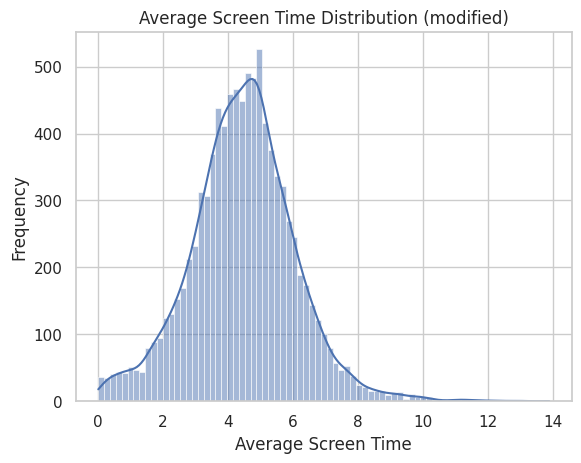

In [ ]:
plt.title('Average Screen Time Distribution (modified)')
sns.histplot(df['avg_scr'], kde=True)
plt.xlabel('Average Screen Time')
plt.ylabel('Frequency')
plt.show()


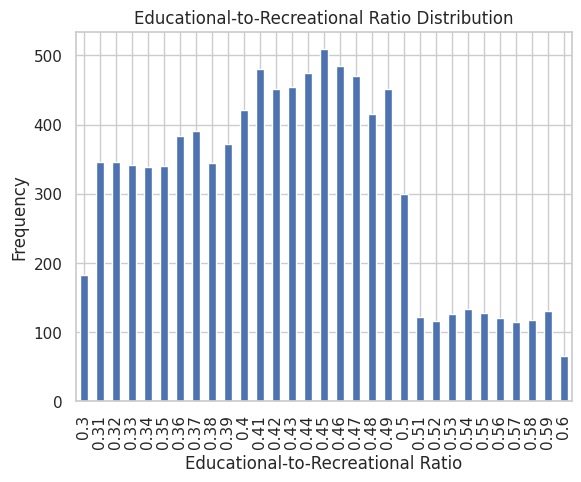

In [ ]:
plt.title('Educational-to-Recreational Ratio Distribution')
df['ratio'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Educational-to-Recreational Ratio')
plt.ylabel('Frequency')
plt.show()

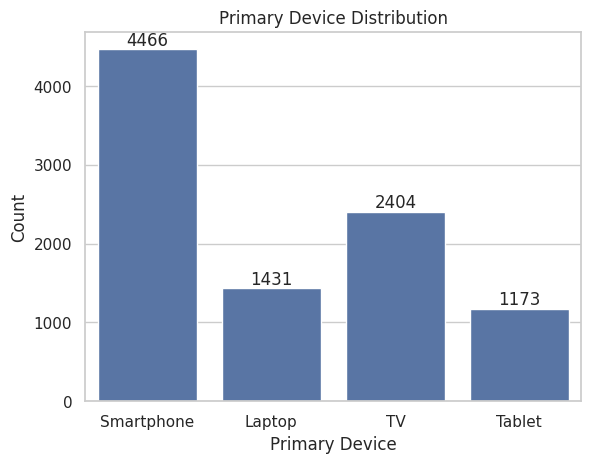

In [ ]:
ax=sns.countplot(x='primary_device', data=df)
ax.bar_label(ax.containers[0])
plt.title('Primary Device Distribution')
plt.xlabel('Primary Device')
plt.ylabel('Count')
plt.show()

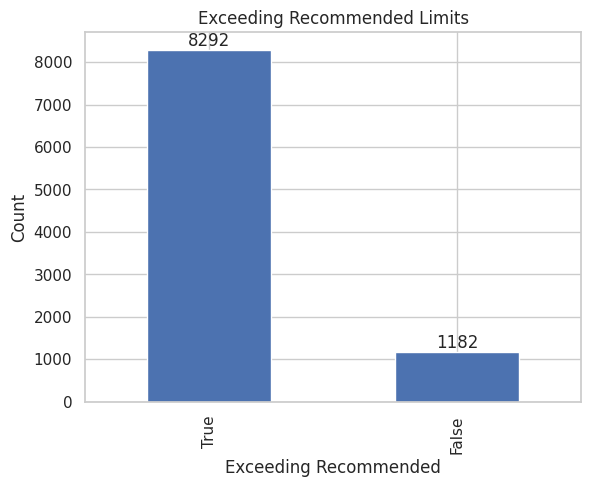

In [ ]:
ax=df['exceeding'].value_counts().plot(kind='bar')
ax.bar_label(ax.containers[0])
plt.title('Exceeding Recommended Limits')
plt.xlabel('Exceeding Recommended')
plt.ylabel('Count')
plt.show()

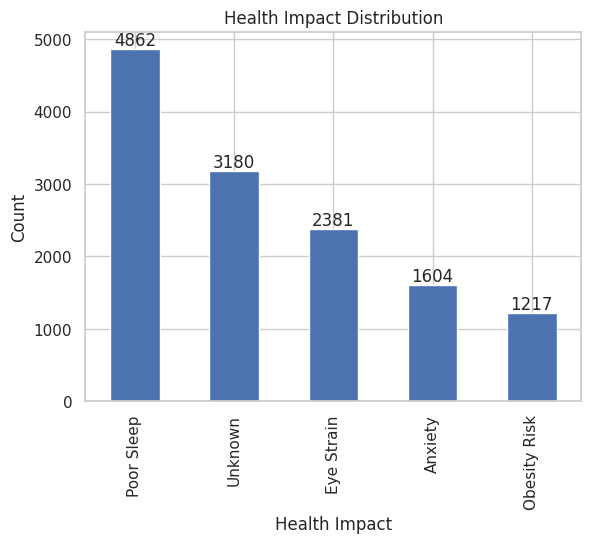

In [ ]:
plt.title('Health Impact Distribution')
bar=explode['health_list'].value_counts().plot(kind='bar')
bar.bar_label(bar.containers[0])
plt.xlabel('Health Impact')
plt.ylabel('Count')
plt.show()

## Bivariate Analysis

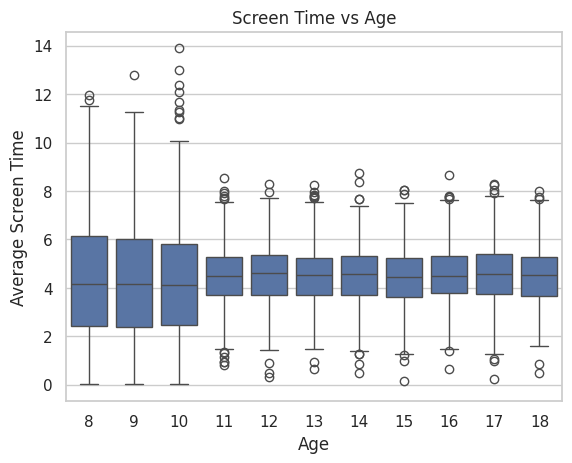

,avg_scr
age,
10,4.12
8,4.14
9,4.17
15,4.43
11,4.49
16,4.51
13,4.52
18,4.54
17,4.56


In [ ]:
sns.boxplot(x='age', y='avg_scr', data=df)
plt.title('Screen Time vs Age')
plt.xlabel('Age')
plt.ylabel('Average Screen Time')
plt.show()

df.groupby('age')['avg_scr'].median().sort_values()

###***Insight***
- median screentime remains fairly consistent across all age groups,
- ranging from 4.12 to 4.60 hours.
- while some age groups, particularly age 10, contain extreme outliers going upto 13+ hours
- the typical screen time pattern is similar regardless of age.

In [ ]:
df['avg_scr'].quantile([0.95, 0.99])

,avg_scr
0.95,6.9900
0.99,8.7527


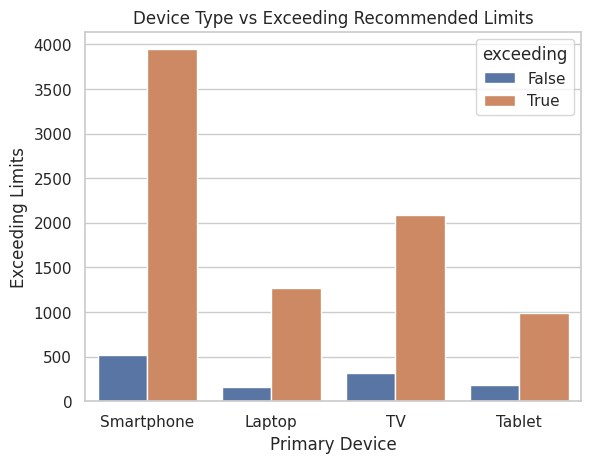

,exceeding
primary_device,
Laptop,88.958770
Smartphone,88.311688
TV,86.647255
Tablet,84.569480


In [ ]:
sns.countplot(x='primary_device', hue='exceeding', data=df)
plt.title('Device Type vs Exceeding Recommended Limits')
plt.xlabel('Primary Device')
plt.ylabel('Exceeding Limits')
plt.show()
df.groupby('primary_device')['exceeding'].mean()*100

###***Insight***
- kids exceed the recommended limits across all primary devices.
- the graph is slightly misleading because smartphones have a much larger population in the dataset to begin with.
- higher raw counts do not necessarily mean a higher exceedance rate.
- when comparing percentages, exceedance rates are similar across all devices (84-89%).

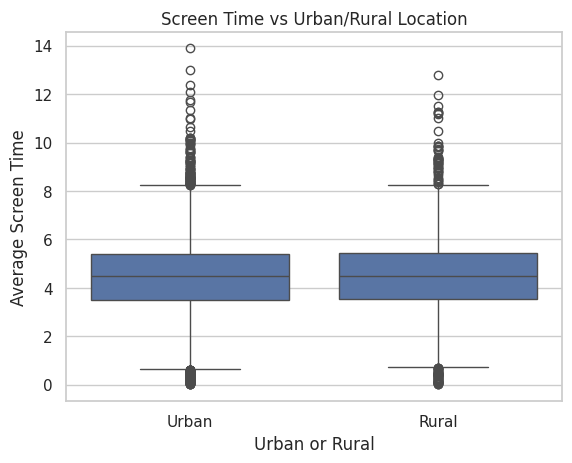

,avg_scr
urban_or_rural,
Rural,4.51
Urban,4.47


In [ ]:
sns.boxplot(x='urban_or_rural', y='avg_scr', data=df)
plt.title('Screen Time vs Urban/Rural Location')
plt.xlabel('Urban or Rural')
plt.ylabel('Average Screen Time')
plt.show()

df.groupby('urban_or_rural')['avg_scr'].median()

###***Insight***
- urban and rural users have almost identical median screen times.
- median was used because avg_scr is skewed and outliers would affect the mean.
- the difference is only 0.04 hours (~2.4 minutes), which is negligible.
- no strong evidence that location influences screen time behaviour.

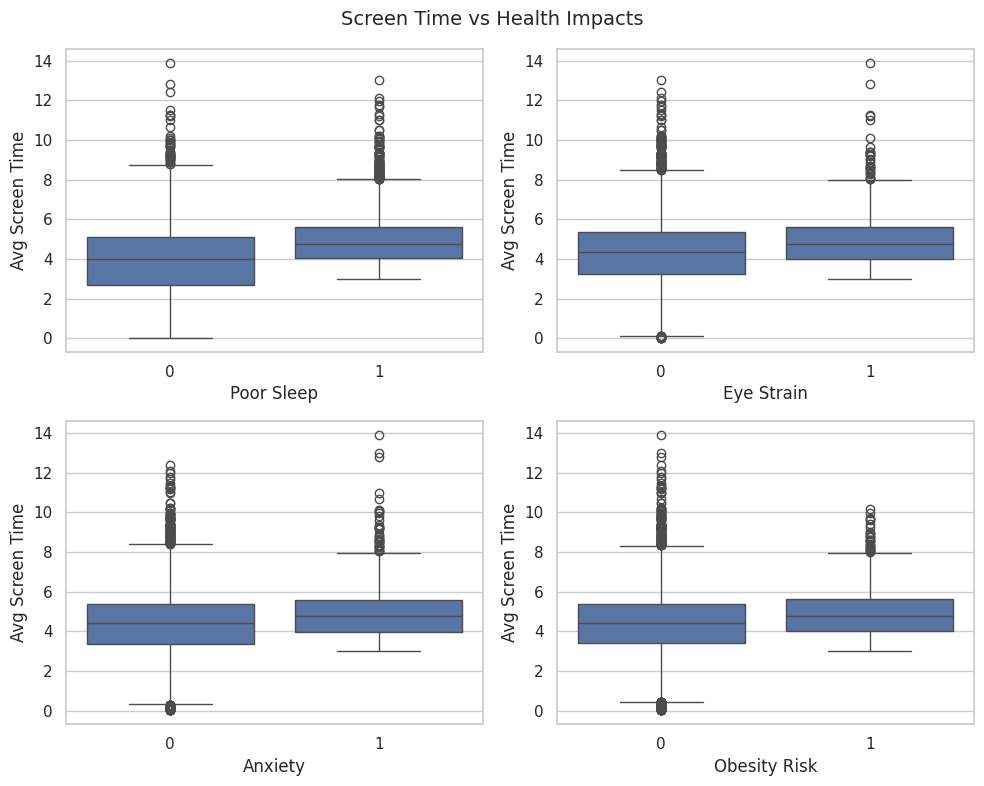

,poor_sleep,eye_strain,anxiety,obesity_risk
0,3.98,4.36,4.410,4.43
1,4.76,4.76,4.765,4.76
difference,0.78,0.40,0.355,0.33


In [ ]:
fig, ax = plt.subplots(2,2, figsize=(10,8))

features = ['poor_sleep', 'eye_strain', 'anxiety', 'obesity_risk']

x_labels = ['Poor Sleep', 'Eye Strain', 'Anxiety', 'Obesity Risk']
y_label = 'Avg Screen Time'

axes = ax.flatten()

for i, feature in enumerate(features):
    sns.boxplot(x=feature, y='avg_scr', data=df, ax=axes[i])
    axes[i].set_xlabel(x_labels[i])
    axes[i].set_ylabel(y_label)

fig.suptitle('Screen Time vs Health Impacts', fontsize=14)

plt.tight_layout()
plt.show()

# List of your binary features
features = ['poor_sleep', 'eye_strain', 'anxiety', 'obesity_risk']

df_list = [df.groupby(f)['avg_scr'].median()for f in features]
result = pd.concat(df_list, axis=1, keys=features)
result.loc['difference'] = result.loc[1] - result.loc[0]
result

#relationship exists but separation is weak. poor sleep has the highest difference.

###***Insight***
- The subplot shows kids having health issues generally have higher average screen time
- This trend is consistent across all health impact variables

- However, there is noticeable overlap between distributions which suggests the relationship exists but is not very strong or extreme
- Among all factors, poor sleep shows the highest median difference, suggesting it may be the most strongly linked to screen time.

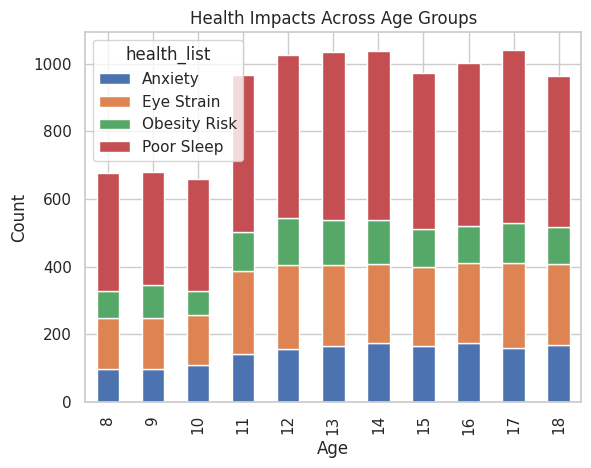

In [ ]:
explode.groupby('age')['health_list'].value_counts().unstack().drop(columns='Unknown').plot(kind='bar',stacked=True)
plt.title('Health Impacts Across Age Groups')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

###***Insight***
- Poor sleep is the most commonly reported health impact across all age groups.
- The frequency of reported health impacts appears to increase from around age 11 onwards.

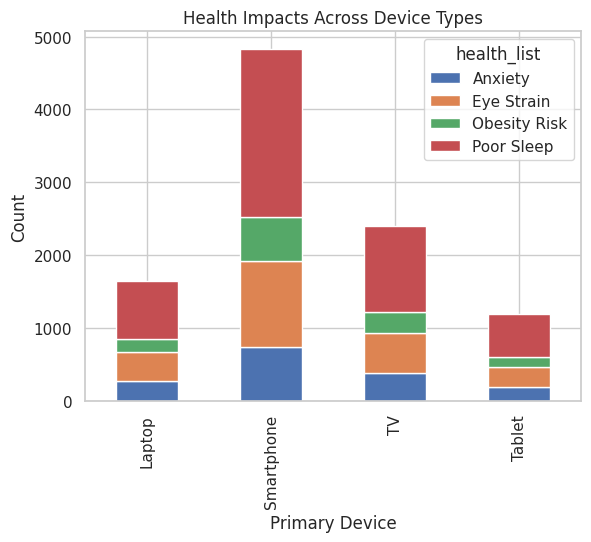

In [ ]:
ax=explode.groupby('primary_device')['health_list'].value_counts().unstack().drop(columns='Unknown').plot(kind='bar',stacked=True)
plt.title('Health Impacts Across Device Types')
plt.xlabel('Primary Device')
plt.ylabel('Count')
plt.show()

###***Insight***
- Smartphone users are associated with poor sleep compared to other device users.
- May be because of huge population of smartphone users

## Multivariate Analysis

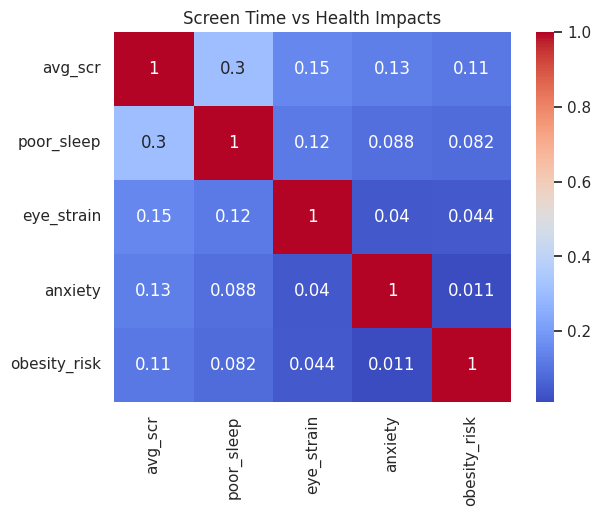

In [ ]:
cols=['avg_scr','poor_sleep','eye_strain','anxiety','obesity_risk']
sns.heatmap(df[cols].corr(),annot=True,cmap='coolwarm')
plt.title('Screen Time vs Health Impacts')
plt.show()

###***Insight***
- Poor sleep has the highest correlation, comparitively, with screen time (~0.30).
- Eye strain, anxiety and obesity risk also show positive correlations, but they are weaker.
- Correlations between the health impacts themselves are low, indicating no strong relationship between them.

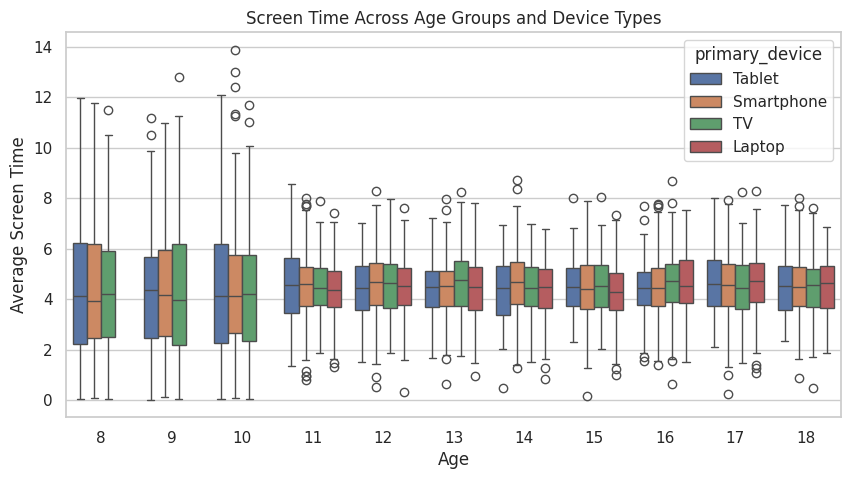

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(x='age',y='avg_scr',hue='primary_device',data=df)
plt.title('Screen Time Across Age Groups and Device Types')
plt.xlabel('Age')
plt.ylabel('Average Screen Time')
plt.show()

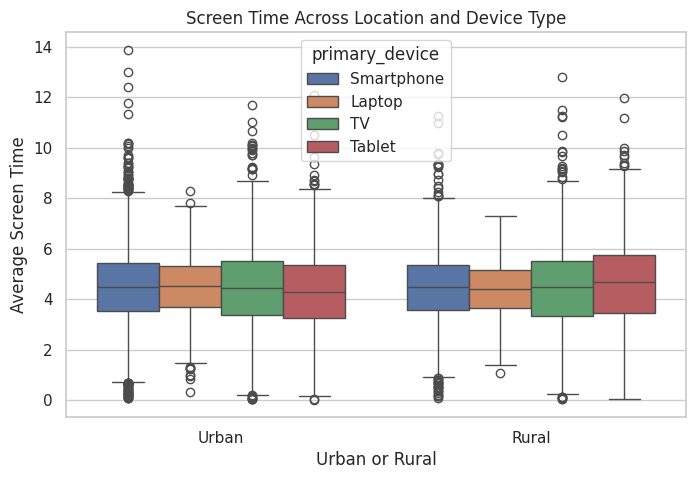

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='urban_or_rural', y='avg_scr', hue='primary_device', data=df)
plt.title('Screen Time Across Location and Device Type')
plt.xlabel('Urban or Rural')
plt.ylabel('Average Screen Time')
plt.show()

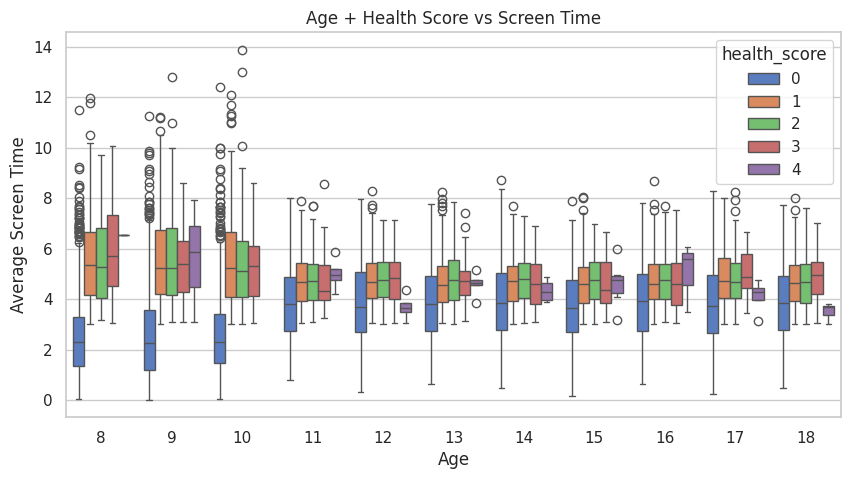

In [ ]:
df['health_score'] = df[['poor_sleep','eye_strain','anxiety','obesity_risk']].sum(axis=1)
plt.figure(figsize=(10,5))
sns.boxplot(x='age', y='avg_scr', hue='health_score', data=df,palette='muted')
plt.title("Age + Health Score vs Screen Time")
plt.xlabel('Age')
plt.ylabel('Average Screen Time')
plt.show()

# **Statistical Analysis**

##Normality Check

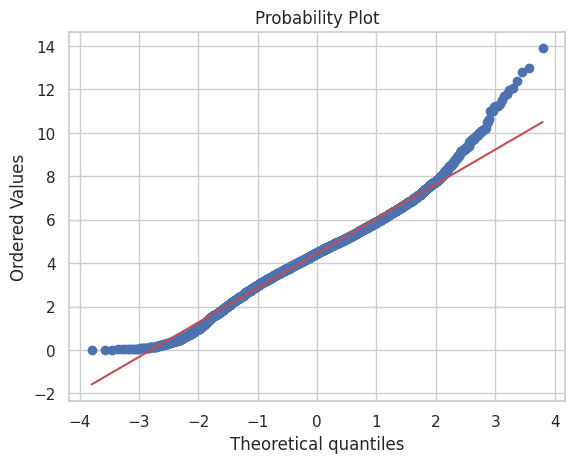

In [ ]:
from scipy import stats
stats.probplot(df['avg_scr'],dist='norm',plot=plt)
plt.show()

###***Insight***
Average screen time is not perfectly normally distributed and exhibits positive skewness.

In [ ]:
from scipy.stats import shapiro
stat, p = shapiro(df['avg_scr'].sample(500, random_state=42))
print(stat)
print(p)

0.9891110603330587
0.0009016956163057791


###***Insight***
- The QQ plot shows a positive skew and the Shapiro-Wilk test is significant, indicating avg_scr is not normally distributed.
- However, due to the large sample size, the t-test is still considered appropriate as it is generally robust to moderate departures from normality.

###Hypothesis Test 1: Screen Time vs Poor Sleep
***H₀***: *Children with poor sleep and children without poor sleep have the same average screen time*

***H₁***: *Children with poor sleep and children without poor sleep have different average screen times.*

In [ ]:
from scipy.stats import ttest_ind

poorsleep=df[df['poor_sleep']==1]['avg_scr']
non_poorsleep=df[df['poor_sleep']==0]['avg_scr']

stat,p=ttest_ind(poorsleep,non_poorsleep,equal_var=False)
print('t-test value: ',stat)
print('p-value:',p)

t-test value:  30.85166327585439
p-value: 6.251267413739501e-198


In [ ]:
df.groupby('poor_sleep')['avg_scr'].median()

,avg_scr
poor_sleep,
0,3.98
1,4.76


In [ ]:
(4.76-3.98)*60
#children with poor sleep has 47 mins more screentime more which looks very less so we look further

46.79999999999999

### ***Insight***

- We reject the null hypothesis indicating there is a significant difference in screentime between kids reporting poor sleep and those who do not

- However, the difference in screen time is approximately 47 minutes which needs further investigation

- To check if this difference is practically meaningful, Cohen's d was calculated.

In [ ]:
import numpy as np

mean_diff = poorsleep.mean() - non_poorsleep.mean()

pooled_std = np.sqrt(
    (
        (poorsleep.std()**2) +
        (non_poorsleep.std()**2)
    ) / 2
)

cohens_d = mean_diff / pooled_std

print(cohens_d)

0.6369096006709196


### ***Insight***

- Cohen's d = 0.64 indicates a moderate-to-large effect size.

- This suggests that the difference in screen time between the two groups is not only statistically significant but also meaningful in practice.

- Therefore, children reporting poor sleep tend to have noticeably higher screen time than those who do not.

### Test 2: Urban vs Rural Screen Time


***H₀***: *Urban and rural children have the same average screen time*

***H₁:*** *Urban and rural children have different average screen times*

In [ ]:
urban=df[df['urban_or_rural']=='Urban']['avg_scr']
rural=df[df['urban_or_rural']=='Rural']['avg_scr']

stat,p=ttest_ind(urban,rural,equal_var=False)
print(stat)
print(p,'\n')

df.groupby('urban_or_rural')['avg_scr'].median()

-0.6021891204633797
0.5470748601557385 



,avg_scr
urban_or_rural,
Rural,4.51
Urban,4.47


###***Insight***
The difference between screentime in urban and rural areas is only approximately 2 minutes which is negligible

### Test 3: Device Type vs Exceeding IAP Limits

***H₀:*** *Device type and exceeding screen-time limits are not associated (independent)*

***H₁:*** *Device type and exceeding screen-time limits are associated*

In [ ]:
table=df.groupby('primary_device')['exceeding'].value_counts().unstack()

In [ ]:
from scipy.stats import chi2_contingency
chi2,p,dof,exp=chi2_contingency(table)
print(chi2)
print(p)

16.304503299887138
0.0009820808606161842


In [ ]:
df.groupby('primary_device')['exceeding'].mean()*100

,exceeding
primary_device,
Laptop,88.958770
Smartphone,88.311688
TV,86.647255
Tablet,84.569480


###***Insight***
Device type and exceeding recommended screen-time limits are associated but all the values look very close by so we look into it further

In [ ]:
n = table.sum().sum()

cramers_v = np.sqrt(
    chi2 / (n * (min(table.shape)-1))
)

print(cramers_v)

0.04148461809023162


###***Insight***
- The effect size is negligible.
- So even tho there is a association the relationship is very weak.
- This indicates that screentime is widespread across all devices

### Test 4: Age vs Screen Time

***H₀:*** *There is no relationship between age and average screen time*

***H₁*** *There is a relationship between age and average screen time*

In [ ]:
from scipy.stats import spearmanr

corr, p = spearmanr(df['age'], df['avg_scr'])
print(corr)
print(p)

0.05830656663754702
1.3522970919571588e-08


###***Insight***
The relationship is significant between age and screen time, but the strength of the relationship is extremely weak, meaning age explains very little of the variation in screen time.

## **Final Conclusions**
- Overall, screen time among children is fairly high and consistent, with most children spending around 4–5 hours per day on screens. T
- Age has a statistically significant relationship with screen time, but the relationship is very weak
- Children reporting health impacts, especially poor sleep, tend to have higher screen time. However, the overlap between groups shows the relationship exists but is not very strong.
- Device type does not significantly influence screen time behavior. Even though smartphones dominate the dataset, all device users show similar patterns of exceeding recommended limits.
- There is no meaningful difference in screen time between urban and rural children.
- Most statistical tests show significance, but effect sizes are generally small, meaning the relationships are not practically strong even if they are statistically valid.
- Overall, screen time appears to be a widespread and uniform behavior, with only weak influences from location or device-based factors.